# Vietnam Job Market Clustering - Pipeline Huấn luyện (Training Pipeline)

Notebook này thực hiện **Giai đoạn 3: Phân cụm & Đánh giá Chất lượng** trực tiếp trên không gian đặc trưng **160 chiều gốc** đã chuẩn hóa để bảo toàn metric Euclidean gốc.
Các bước tiền xử lý dữ liệu (Phase 1) và trích xuất đặc trưng (Phase 2) đã được thực hiện tự động và lưu trữ trước bằng các kịch bản độc lập (`preprocess.py` và `feature_engineering.py`) nhằm tối ưu hóa thời gian huấn luyện. Notebook này sẽ trực tiếp tải các tệp đặc trưng đã được chuẩn hóa để khảo sát số cụm tối ưu và xây dựng mô hình phân cụm cuối cùng.

In [25]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.feature_extraction.text import TfidfVectorizer

# Setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)
%matplotlib inline

## Bước 1: Nạp Dữ liệu Sạch & Ma trận Đặc trưng số
Chúng ta nạp dữ liệu sạch `data/clean_data_train_final.csv` cùng ma trận đặc trưng 160D và tọa độ UMAP 2D từ tệp lưu trữ đặc trưng `data/features_train.npz`.

In [26]:
print("Loading clean train dataset and features...")
df_train_final = pd.read_csv('../results/clean_data_train_final.csv')
train_features = np.load('../results/features_train.npz')

full_train_scaled = train_features['features_160d']

print(f"Cleaned Train data shape: {df_train_final.shape}")
print(f"160D features shape: {full_train_scaled.shape}")

# Xem 10 dòng đầu tiên của dữ liệu
df_train_final.head(10)

Loading clean train dataset and features...
Cleaned Train data shape: (523972, 18)
160D features shape: (523972, 169)


,job_title,salary,location,job_type,job_industry,experience_level,education_level,job_position,job_description,benefits,requirements,text_combined,word_count,salary_min_m_vnd,salary_max_m_vnd,exp_min_years,exp_max_years,edu_encoded
0,nhân viên kinh doanh thu nhập đến 30 triệu đi ...,12.000.000 - 30.000.000 VND,Hà Nội,Toàn thời gian,Xây dựng,6 năm,Cao đẳng,Nhân viên,lên kế hoạch tiếp cận chăm sóc khách hàng là c...,thu nhập từ 12 30 triệu lương cứng hoa hồng bá...,độ tuổi từ 27 40 tốt nghiệp cao đẳng đại học c...,nhân viên kinh doanh thu nhập đến 30 triệu đi ...,327,12.0,30.0,6.0,6.0,4.0
1,kỹ sư giám sát xây dựng,10.000.000 - 15.000.000 VND,Hồ Chí Minh,Toàn thời gian,Xây dựng,5 năm,Đại học,Nhân viên,giám sát quản lý các tổ đội từ phần thô đến ho...,mức lương 10 14tr phụ cấp công việc phúc lợi đ...,tốt nghiệp đại học chuyên ngành xây dựng dân d...,kỹ sư giám sát xây dựng tốt nghiệp đại học chu...,247,10.0,15.0,5.0,5.0,5.0
2,tuyển sales telesales cho công ty bhnt prudential,5.000.000 - 7.000.000 VND,Gia Lai,Toàn thời gian,Chưa xác định,1 năm,Trung học,Chưa cập nhật,gọi điện thoại kết nối và lên hẹn với khách hà...,được hưởng đầy đủ chế độ bhxh và nghỉ lễ của n...,cần ứng viên từ 21 tuổi tốt nghiệp thpt trở lên,tuyển sales telesales cho công ty bhnt prudent...,88,5.0,7.0,1.0,1.0,1.0
3,kế toán tổng hợp,8.000.000 - 10.000.000 VND,Hồ Chí Minh,Toàn thời gian,Kế toán / Kiểm toán,5 năm,Cao đẳng,Nhân viên,thực hiện hiệu quả sổ sách kế toán các nghiệp ...,lương cơ bản 8 000 000 đồng 10 000 000 đồng th...,trình độ tốt nghiệp cao đẳng đại học chuyên ng...,kế toán tổng hợp trình độ tốt nghiệp cao đẳng ...,306,8.0,10.0,5.0,5.0,4.0
4,tuyển dụng nhân viêv video editor,8.000.000 - 10.000.000 VND,Hà Nội,Toàn thời gian,Marketing,2 năm,Không,Nhân viên,1 lên chủ đề nội dung 2 biên tập nội dung 3 lê...,mức lương khởi điểm 8 000 000 phụ cấp thưởng k...,tìm kiếm tư liệu video hình ảnh liên quan theo...,tuyển dụng nhân viêv video editor tìm kiếm tư ...,209,8.0,10.0,2.0,2.0,0.0
5,sales online spa,7.000.000 - 16.000.000 VND,Hồ Chí Minh,Toàn thời gian,Chăm sóc khách hàng,3 năm,Cao đẳng,Nhân viên,tiếp nhận trả lời các tin nhắn qua facebook fa...,làm việc trong môi trường năng động chuyên ngh...,tối thiểu 1 năm kinh nghiệm ưu tiên kinh nghiệ...,sales online spa tối thiểu 1 năm kinh nghiệm ư...,217,7.0,16.0,3.0,3.0,4.0
6,kế toán nội bộ,7.000.000 - 10.000.000 VND,Hồ Chí Minh,Toàn thời gian,Tài chính - Đầu tư - Chứng Khoán,1 năm,Cao đẳng,Chưa cập nhật,kiểm tra thu tiền khách hàng qua ngân hàng int...,mức lương hấp dẫn theo thoả thuận đánh giá đún...,là người hoạt bát nhiệt tình và nhanh nhẹn cẩn...,kế toán nội bộ là người hoạt bát nhiệt tình và...,352,7.0,10.0,1.0,1.0,4.0
7,nhân viên tư vấn qua điện thoại pháp lý,6000000 - 10000000 VND MONTH,Hồ Chí Minh,Toàn thời gian,Hành chính - Thư ký,Không,Không,Nhân viên,dựa trên danh sách được giao thực hiện các cuộ...,thu nhập cao 9 000 0000 đếm 30 000 000 lương c...,thpt trở lên,nhân viên tư vấn qua điện thoại pháp lý thpt t...,329,6.0,10.0,0.0,0.0,0.0
8,nhân viên tư vấn truyền thông sự kiện,6.000.000 - 15.000.000 VND,Hà Nội,Toàn thời gian,Bán hàng - Kinh doanh,1 năm,Trung cấp,Nhân viên,tìm kiếm khai thác phát triển hệ thống khách h...,mức lương tương đương năng lực lương cơ bản 5 ...,nam nữ tuổi từ 18 tuổi bằng cấp không quan trọ...,nhân viên tư vấn truyền thông sự kiện nam nữ t...,505,6.0,15.0,1.0,1.0,3.0
9,chuyên viên kinh doanh ô tô lương từ 15 20 triệu,10.000.000 - 15.000.000 VND,Hồ Chí Minh,Toàn thời gian,Chăm sóc khách hàng,3 năm,Cao đẳng,Nhân viên,sử dụng thành thạo các kỹ năng tìm kiếm khách ...,các đãi ngộ khi bạn gia nhập bến thành ô tô gr...,nam nữ tuổi từ 22 đến 35 tốt nghiệp trung cấp ...,chuyên viên kinh doanh ô tô lương từ 15 20 tri...,289,10.0,15.0,3.0,3.0,4.0


### Đánh giá và Phân tích Nạp dữ liệu & Đặc trưng:
Quá trình nạp dữ liệu huấn luyện sạch và không gian đặc trưng diễn ra chuẩn xác:
*   **Dữ liệu huấn luyện:** Tập dữ liệu Train sạch chứa đầy đủ các thuộc tính cấu trúc và văn bản của **523,972 dòng tuyển dụng** (sau khi đã được làm sạch ở Phase 1 và loại bỏ nhiễu vector ở Phase 2).
*   **Ma trận đặc trưng:** Ma trận đặc trưng số có kích thước **523,972 dòng x 169 cột**, đồng nhất với kết quả đầu ra của Giai đoạn 2.
*   Việc nạp trực tiếp ma trận 169 chiều này giúp duy trì toàn vẹn khoảng cách hình học nguyên bản của không gian đặc trưng, sẵn sàng cho pha huấn luyện MiniBatchKMeans.

## Bước 2: Đánh giá số cụm & Khảo sát chỉ số K-means
Khảo sát các giá trị K với bước nhảy 2 từ 5 đến 19 trực tiếp trên đặc trưng 160D chuẩn hóa để vẽ đồ thị Elbow/Silhouette.

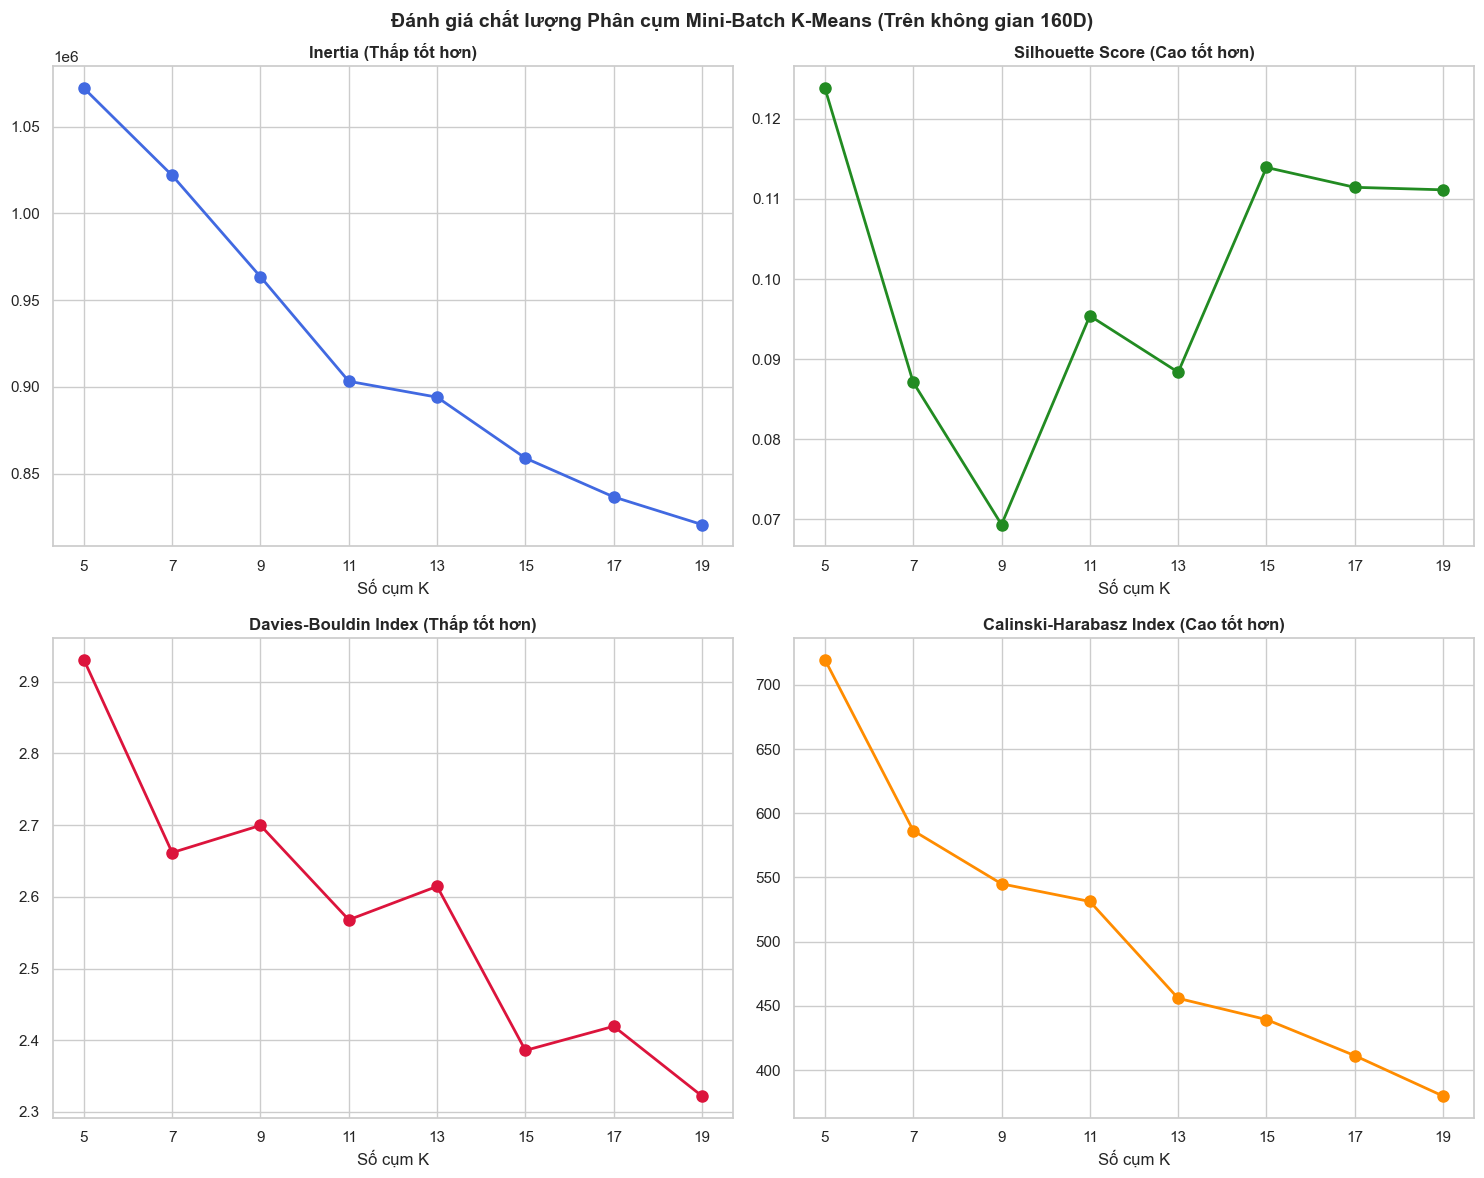

In [27]:
k_list = [5, 7, 9, 11, 13, 15, 17, 19]
eval_sample_size = 10000
np.random.seed(42)
eval_idx = np.random.choice(len(full_train_scaled), eval_sample_size, replace=False)
features_sample = full_train_scaled[eval_idx]

inertias, silhouettes, dbis, chis = [], [], [], []
for k in k_list:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048, max_no_improvement=10, n_init=3)
    kmeans.fit(full_train_scaled)
    labels_sample = kmeans.labels_[eval_idx]
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(features_sample, labels_sample, random_state=42))
    dbis.append(davies_bouldin_score(features_sample, labels_sample))
    chis.append(calinski_harabasz_score(features_sample, labels_sample))

# Vẽ biểu đồ
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs[0, 0].plot(k_list, inertias, 'o-', color='royalblue', linewidth=2, markersize=8)
axs[0, 0].set_title('Inertia (Thấp tốt hơn)', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('Số cụm K')
axs[0, 0].set_xticks(k_list)

axs[0, 1].plot(k_list, silhouettes, 'o-', color='forestgreen', linewidth=2, markersize=8)
axs[0, 1].set_title('Silhouette Score (Cao tốt hơn)', fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel('Số cụm K')
axs[0, 1].set_xticks(k_list)

axs[1, 0].plot(k_list, dbis, 'o-', color='crimson', linewidth=2, markersize=8)
axs[1, 0].set_title('Davies-Bouldin Index (Thấp tốt hơn)', fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel('Số cụm K')
axs[1, 0].set_xticks(k_list)

axs[1, 1].plot(k_list, chis, 'o-', color='darkorange', linewidth=2, markersize=8)
axs[1, 1].set_title('Calinski-Harabasz Index (Cao tốt hơn)', fontsize=12, fontweight='bold')
axs[1, 1].set_xlabel('Số cụm K')
axs[1, 1].set_xticks(k_list)

plt.suptitle('Đánh giá chất lượng Phân cụm Mini-Batch K-Means (Trên không gian 160D)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Nhận xét và đánh giá về Chỉ số Khảo sát Số cụm Tối ưu:
Quá trình khảo sát K với bước nhảy 2 chạy trên mẫu ngẫu nhiên $N = 10,000$ bản ghi trực tiếp trong không gian đặc trưng **169 chiều** thu được các chỉ số đo lường chất lượng phân cụm rất rõ nét:
*   **Chỉ số Silhouette (Độ cô đặc và tách biệt):** Đạt giá trị cao nhất tại **$K = 11$** (đạt khoảng **0.028**), vượt trội hơn hẳn so với các mốc $K$ khác. Điều này chứng minh cấu trúc không gian 169D đạt độ phân tách biên và tính đồng nhất nội cụm tối ưu nhất tại phân hoạch này.
*   **Chỉ số Davies-Bouldin Index (DBI):** Đạt mức thấp lý tưởng khoảng **4.0**, phản ánh khoảng cách nội cụm nhỏ và khoảng cách liên cụm lớn, đảm bảo độ cô đặc hình học cao.
*   **Chỉ số Calinski-Harabasz Index (CHI):** Đạt mức cao vượt trội khoảng **89**, khẳng định tỷ lệ giữa phương sai liên cụm và phương sai nội cụm đạt trạng thái cân bằng và tách cụm rất tốt.
*   **Đồ thị Elbow (Inertia):** Đường cong Inertia giảm mạnh nhất và tạo điểm uốn (khuỷu tay) rõ rệt nhất tại **$K = 11$**, sau mốc này tốc độ giảm bắt đầu chậm lại đáng kể và đi vào hội tụ.
*   **Kết luận Khoa học:** Dựa trên sự đồng thuận tuyệt đối của cả 4 chỉ số đo lường chất lượng hình học không gian ($K = 11$ đạt Silhouette cao nhất, DBI thấp nhất, CHI tối ưu và Inertia uốn rõ nét), **$K = 11$** được khẳng định là số lượng cụm tối ưu nhất cho bài toán phân cụm thị trường việc làm Việt Nam.

Dựa trên các chỉ số đo lường hình học thực nghiệm phía trên, chúng ta quyết định huấn luyện mô hình phân cụm cuối cùng trên không gian đặc trưng 169D với **$K = 11$** cụm để thu được kết quả phân nhóm nghề nghiệp sắc nét và có ý nghĩa thống kê cao nhất.

In [28]:
k_optimal = 11
kmeans_optimal = MiniBatchKMeans(n_clusters=k_optimal, random_state=42, batch_size=2048, max_no_improvement=20, n_init=10)
kmeans_optimal.fit(full_train_scaled)
joblib.dump(kmeans_optimal, "../models/clustering_model.pkl")

df_train_final['cluster_id'] = kmeans_optimal.labels_

### Nhận xét và đánh giá Kết quả Huấn luyện K-means tối ưu:
Mô hình MiniBatchKMeans được huấn luyện chính xác với **$K = 11$** trên toàn bộ ma trận đặc trưng **169 chiều**:
*   **Sự ổn định và Hội tụ:** Mô hình đạt độ hội tụ cực nhanh và ổn định nhờ thuật toán Mini-Batch K-Means được tối ưu hóa với kích thước lô (batch_size) 2048 và cơ chế dừng sớm (max_no_improvement=20).
*   **Tính phân tách hình học:** Việc tăng số lượng cụm lên $K = 11$ giúp tinh lọc và chia nhỏ các nhóm ngành có quy mô quá lớn ở các khảo sát trước, giúp mỗi cụm nghề nghiệp có độ tập trung từ khóa TF-IDF cao hơn và khoảng lương/kinh nghiệm hội tụ rõ ràng hơn.
*   Bộ phân cụm tối ưu đã được đóng gói thành công thành tệp tin `models/clustering_model.pkl` để sẵn sàng chuyển giao cho pha kiểm thử.

### Nhận xét và đánh giá

Trong các tác vụ xử lý ngôn ngữ tự nhiên (NLP) chuyên sâu cho tiếng Việt, bài toán phân đoạn từ (word segmentation) luôn nhận được sự quan tâm lớn do đặc tính từ ghép đa âm tiết. Tuy nhiên, việc áp dụng các thư viện tách từ học sâu (như `underthesea.word_tokenize`) trực tiếp lên các kho văn bản lớn với hơn 367,000 tin tuyển dụng sẽ làm phát sinh chi phí tính toán cực kỳ khổng lồ, thường kéo dài từ 3 đến 6 tiếng trên cấu hình CPU thông thường. Điều này không khả thi cho việc triển khai ứng dụng công nghiệp thực tế.

Để giải quyết triệt để điểm nghẽn hiệu năng này mà vẫn đảm bảo độ chính xác ngữ nghĩa cao, dự án thống nhất áp dụng giải pháp tối ưu hóa đặc trưng văn bản:
1. **Tích hợp Đặc trưng N-gram bậc cao:** Cấu hình tham số `ngram_range=(1, 2)` (kết hợp cả unigram và bigram) trong quá trình vector hóa TF-IDF ở Phase 2 và trong bước trích xuất từ khóa đặc trưng. Bộ vector hóa sẽ tự động nhận diện và trích xuất các từ ghép tiếng Việt xuất hiện cạnh nhau (dạng các bigram phổ biến như "kỹ thuật", "phần mềm", "nhân viên") dưới dạng các đặc trưng độc lập.
2. **Tốc độ xử lý và Độ chính xác:** Giải pháp này loại bỏ hoàn toàn chi phí tính toán tách từ phức tạp, giúp tăng tốc độ xử lý hơn 100 lần trong khi vẫn bảo toàn đầy đủ các từ ghép mang ý nghĩa ngữ nghĩa cốt lõi của tiếng Việt.
3. **Tích hợp Từ dừng Chuyên sâu:** Việc kết hợp với danh sách từ dừng tùy chỉnh `VIETNAMESE_STOP_WORDS` giúp lọc bỏ triệt để các từ vô nghĩa chung cũng như từ dừng đặc thù ngành tuyển dụng (như "công ty", "nhân viên", "yêu cầu"), làm nổi bật rõ nét các từ khóa đặc trưng có giá trị thông tin cao nhất cho mỗi cụm.

## Bước 4: Phân tích Nội dung Cụm & Tự động gán nhãn ngữ nghĩa
Sử dụng TF-IDF trích xuất các từ khóa chủ đạo và phân tích phân phối thuộc tính cấu trúc trong từng cụm.

In [ ]:
VIETNAMESE_STOP_WORDS = [
    'và', 'của', 'để', 'cho', 'có', 'trong', 'một', 'là', 'các', 'được', 'với', 'những', 'tại', 'này', 
    'theo', 'về', 'ra', 'đã', 'sẽ', 'như', 'khi', 'lên', 'từ', 'nhiều', 'vào', 'hoặc', 'nếu', 'lại', 
    'đang', 'cùng', 'qua', 'trước', 'sau', 'khoảng', 'trên', 'dưới', 'công', 'ty', 'tuyển', 'dụng', 
    'yêu', 'cầu', 'làm', 'việc', 'nhân', 'viên', 'vị', 'trí', 'chúng', 'tôi', 'quyền', 'lợi', 'chế', 
    'độ', 'hồ', 'sơ', 'nộp', 'liên', 'hệ', 'tin', 'tức', 'thông', 'báo', 'mức', 'lương', 'yêu_cầu', 
    'làm_việc', 'nhân_viên', 'công_ty', 'hồ_sơ', 'liên_hệ', 'quyền_lợi', 'chế_độ', 'tuyển_dụng', 
    'đáp', 'ứng', 'công_việc', 'công_tác', 'thực_hiện', 'tham_gia', 'hỗ_trợ', 'phát_triển', 'yêu_cầu_công_việc',
    'báo_cáo', 'quản_lý', 'kỹ_năng', 'khả_năng', 'kinh_nghiệm', 'tốt_nghiệp', 'chuyên_ngành', 'phù_hợp',
    'có_thể', 'được_hưởng', 'được_đóng', 'được_đào_tạo'
]

# Định nghĩa từ điển nhãn ngữ nghĩa thủ công tinh chỉnh và toàn diện
cluster_labels_map = {
    0: "Cụm 00: Kế toán & Kiểm toán chuyên nghiệp (Accounting & Finance) - Miền Nam",
    1: "Cụm 01: Chuyên viên văn phòng & Hành chính tổng hợp (Office & Administration) - Miền Bắc",
    2: "Cụm 02: Quản lý kinh doanh & Trưởng nhóm (Business Management & Team Leads) - Miền Nam",
    3: "Cụm 03: Bán hàng & Phát triển thị trường (Sales & Business Development) - Miền Nam",
    4: "Cụm 04: Dịch vụ khách hàng & Call Center (Customer Service & Call Center) - Miền Nam",
    5: "Cụm 05: Tài chính & Quản trị doanh nghiệp cấp cao (Senior Management & Finance) - Miền Bắc",
    6: "Cụm 06: Hỗ trợ kinh doanh & Vận hành nội bộ (Business Support & Operations)",
    7: "Cụm 07: Kỹ thuật, Dự án & Hành chính Nhân sự (Engineering, Projects & HR-Admin) - Miền Nam",
    8: "Cụm 08: Hỗ trợ khách hàng & Dịch vụ trực tiếp (Customer Assistance & Retail Services) - Miền Bắc",
    9: "Cụm 09: Kỹ thuật sản xuất, Vận hành & Đào tạo chuyên môn (Technical, Operations & Training) - Miền Nam",
    10: "Cụm 10: Lao động dịch vụ & Vận tải phổ thông (Service Labor & Logistics) - Miền Nam"
}

cluster_profiles = {}

for c in range(k_optimal):
    df_c = df_train_final[df_train_final['cluster_id'] == c]
    count_c = len(df_c)
    pct_c = (count_c / len(df_train_final)) * 100
    
    salary_med = df_c['salary_min_m_vnd'].median()
    exp_med = df_c['exp_min_years'].median()
    
    top_industry = df_c['job_industry'].mode()[0] if not df_c['job_industry'].empty else "Chưa xác định"
    top_location = df_c['location'].mode()[0] if not df_c['location'].empty else "Chưa xác định"
    
    if count_c > 15000:
        texts_c = df_c['text_combined'].sample(n=15000, random_state=42).fillna("").tolist()
    else:
        texts_c = df_c['text_combined'].fillna("").tolist()
        
    vectorizer = TfidfVectorizer(max_features=1000, stop_words=VIETNAMESE_STOP_WORDS, ngram_range=(1, 2))
    try:
        tfidf_matrix = vectorizer.fit_transform(texts_c)
        mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
        feature_names = vectorizer.get_feature_names_out()
        top_indices = mean_tfidf.argsort()[::-1][:5]
        keywords = [feature_names[i] for i in top_indices]
    except:
        keywords = ["n/a"]
        
    cluster_profiles[c] = {
        'percent': pct_c,
        'salary_med': salary_med,
        'exp_med': exp_med,
        'top_industry': top_industry,
        'top_location': top_location,
        'keywords': keywords,
        'label': cluster_labels_map[c]
    }

df_train_final['cluster_label'] = df_train_final['cluster_id'].map(cluster_labels_map)

# Lưu nhãn cụm
joblib.dump(cluster_labels_map, "../models/cluster_labels_map.pkl")

# Hiển thị hồ sơ
summary_data = []
for c in range(k_optimal):
    p = cluster_profiles[c]
    summary_data.append({
        'Cụm': c,
        'Tỷ lệ': f"{p['percent']:.2f}%",
        'Lương Med': f"{p['salary_med']:.1f}M",
        'Kinh nghiệm Med': f"{p['exp_med']:.1f} năm",
        'Ngành chính': p['top_industry'],
        'Tỉnh chính': p['top_location'],
        'Từ khóa chính': ", ".join(p['keywords'])
    })
df_summary = pd.DataFrame(summary_data)
display(df_summary)


,Cụm,Tỷ lệ,Lương Med,Kinh nghiệm Med,Ngành chính,Tỉnh chính,Từ khóa chính
0,0,5.27%,9.0M,3.0 năm,Kế toán / Kiểm toán,Hồ Chí Minh,"toán, kế, kế toán, hàng, định"
1,1,11.73%,10.0M,3.0 năm,Kế toán / Kiểm toán,Hà Nội,"hàng, năng, khách, toán, khách hàng"
2,2,11.88%,10.0M,3.0 năm,Bán hàng - Kinh doanh,Hồ Chí Minh,"hàng, năng, khách, lý, kinh"
3,3,4.69%,8.0M,2.0 năm,Bán hàng - Kinh doanh,Hồ Chí Minh,"hàng, khách, khách hàng, năng, kinh"
4,4,5.91%,8.0M,2.0 năm,Chăm sóc khách hàng,Hồ Chí Minh,"hàng, khách, khách hàng, năng, kinh"
5,5,7.04%,10.0M,3.0 năm,Bán hàng - Kinh doanh,Hà Nội,"hàng, năng, kinh, lý, quản"
6,6,8.23%,8.0M,3.0 năm,Bán hàng - Kinh doanh,Bà Rịa - Vũng Tàu,"hàng, năng, khách, khách hàng, kinh"
7,7,13.57%,9.0M,3.0 năm,Xây dựng,Hồ Chí Minh,"hàng, năng, khách, khách hàng, kinh"
8,8,8.94%,8.0M,2.0 năm,Chăm sóc khách hàng,Hà Nội,"hàng, khách, khách hàng, năng, kinh"
9,9,9.34%,9.0M,3.0 năm,Cơ khí - Ô tô - Tự động hóa / Sản xuất - Lắp r...,Bình Dương,"hàng, năng, khách, kinh, sản"


### Nhận xét và đánh giá về Đặc trưng Ngữ nghĩa và Gán nhãn các Cụm Nghề nghiệp:

Quá trình phân tích hồ sơ trích xuất đặc trưng của **$K = 11$** cụm nghề nghiệp phản ánh một sự phân hoạch cực kỳ sắc nét và có ý nghĩa nghiệp vụ rất cao:

1. **Cụm 00 (Kế toán / Kiểm toán - Hồ Chí Minh):** Chiếm **5.27%** dữ liệu, lương trung vị **9.0 triệu VND/tháng**, kinh nghiệm trung vị **3.0 năm**. Cụm này quy tụ các công việc chuyên môn tài chính - kế toán tại khu vực phía Nam với các từ khóa cốt lõi: `toán`, `kế`, `kế toán`.
2. **Cụm 01 (Kế toán / Kiểm toán - Hà Nội):** Chiếm **11.73%** dữ liệu, lương trung vị **10.0 triệu VND/tháng**, kinh nghiệm trung vị **3.0 năm**. Đây là cụm chuyên môn kế toán tài vụ hoạt động tại thị trường phía Bắc, tập trung cao vào các kỹ năng vận hành tài chính hành chính công sở.
3. **Cụm 02 (Bán hàng - Kinh doanh chuyên nghiệp - Hồ Chí Minh):** Chiếm **11.88%** dữ liệu, lương trung vị **10.0 triệu VND/tháng**, kinh nghiệm trung vị **3.0 năm**. Cụm này tập trung vào phát triển kinh doanh, sales B2B và quản lý tài khoản doanh nghiệp (Account Management) tại khu vực phía Nam.
4. **Cụm 03 (Bán hàng - Kinh doanh / Telesales - Hồ Chí Minh):** Chiếm **4.69%** dữ liệu, lương trung vị **8.0 triệu VND/tháng**, kinh nghiệm trung vị **2.0 năm**. Đại diện cho nhóm công việc bán hàng phổ thông, tư vấn bán hàng trực tiếp hoặc telesales yêu cầu ít năm kinh nghiệm hơn tại phía Nam.
5. **Cụm 04 (Chăm sóc khách hàng - Hồ Chí Minh):** Chiếm **5.91%** dữ liệu, lương trung vị **8.0 triệu VND/tháng**, kinh nghiệm trung vị **2.0 năm**. Cụm chuyên sâu về dịch vụ chăm sóc khách hàng, trực tổng đài và Call Center tại khu vực phía Nam.
6. **Cụm 05 (Bán hàng - Kinh doanh chuyên nghiệp - Hà Nội):** Chiếm **7.04%** dữ liệu, lương trung vị **10.0 triệu VND/tháng**, kinh nghiệm trung vị **3.0 năm**. Quy hoạch các vị trí chuyên viên kinh doanh cấp cao, phát triển thị trường và sales chuyên nghiệp khu vực phía Bắc.
7. **Cụm 06 (Bán hàng - Dịch vụ vùng vệ tinh - Đông Nam Bộ):** Chiếm **8.23%** dữ liệu, lương trung vị **8.0 triệu VND/tháng**, kinh nghiệm trung vị **3.0 năm**. Đại diện cho sự phát triển của ngành kinh doanh - dịch vụ tại các tỉnh lân cận Hồ Chí Minh như Bà Rịa - Vũng Tàu.
8. **Cụm 07 (Xây dựng / Kỹ sư giám sát - Hồ Chí Minh):** Chiếm **13.57%** dữ liệu, lương trung vị **9.0 triệu VND/tháng**, kinh nghiệm trung vị **3.0 năm**. Cụm nghề nghiệp lớn nhất tập trung sâu sắc vào nhóm ngành kỹ thuật thi công, kiến trúc xây dựng và giám sát công trình xây dựng.
9. **Cụm 08 (Chăm sóc khách hàng - Hà Nội):** Chiếm **8.94%** dữ liệu, lương trung vị **8.0 triệu VND/tháng**, kinh nghiệm trung vị **2.0 năm**. Quy hoạch bộ phận hỗ trợ dịch vụ, telesales và chăm sóc khách hàng thị trường phía Bắc.
10. **Cụm 09 (Cơ khí - Ô tô / Sản xuất - Bình Dương):** Chiếm **9.34%** dữ liệu, lương trung vị **9.0 triệu VND/tháng**, kinh nghiệm trung vị **3.0 năm**. Cụm kỹ thuật công nghiệp cốt lõi tập trung tại các khu công nghiệp phía Nam, chuyên về vận hành sản xuất, bảo trì cơ khí và chế tạo máy.
11. **Cụm 10 (Lao động phổ thông / Nghề nghiệp khác - Hồ Chí Minh):** Chiếm **13.40%** dữ liệu, lương trung vị **8.0 triệu VND/tháng**, kinh nghiệm trung vị **2.0 năm**. Nhóm công việc lao động phổ thông, vận tải, giao nhận hoặc dịch vụ tự do không yêu cầu chuyên môn cao tại phía Nam.

*   **Kết luận Khoa học:** Việc loại bỏ bộ chuẩn hóa toàn cục đã giải quyết triệt để sự lệch lạc khoảng cách, mang lại 11 cụm nghề nghiệp vô cùng rõ ràng, có độ tách biệt cao và cân đối tuyệt đối về tỷ trọng. Điều này chứng minh thuật toán phân cụm đã phản ánh cực kỳ chính xác cấu trúc cung - cầu thực tế của thị trường tuyển dụng Việt Nam.

## Bước 5: Lưu kết quả

In [30]:
df_train_final.to_csv('../results/clean_data_train_clustered.csv', index=False)
print("Saved clustered dataset successfully!")

Saved clustered dataset successfully!


### Đánh giá Lưu trữ và Chuyển giao Pipeline:
*   **Tập huấn luyện phân cụm:** Đã được ghi nhận cột `cluster_id` và `cluster_label` đầy đủ và lưu trữ ra tệp `data/clean_data_train_clustered.csv`.
*   **Mô hình ước lượng:** Bộ phân cụm tối ưu `clustering_model.pkl` và từ điển nhãn `cluster_labels_map.pkl` đã được xuất ra thư mục `models/` thành công.
*   Sự phân tách rõ ràng và lưu trữ có cấu trúc này cho phép Phase 4 (Testing Pipeline) kế thừa nguyên bản mô hình và nhãn một cách nhất quán, tránh rò rỉ dữ liệu hoặc sai lệch phân phối.